<h1>1.Import Library</h1>

In [1]:
!pip install timm

In [2]:
import os
import json
import random
import warnings
import wandb
warnings.simplefilter(action="ignore", category=FutureWarning)

import tqdm
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.multiprocessing as mp
import matplotlib.pyplot as plt

import datetime
import traceback
import shutil

import torch
import torchvision
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms

import torch.optim as optim
from torch.autograd import Variable
from torch.optim.lr_scheduler import MultiplicativeLR, StepLR, MultiStepLR, ConstantLR, LinearLR, PolynomialLR, CosineAnnealingLR, LambdaLR, ChainedScheduler, ExponentialLR, SequentialLR, ReduceLROnPlateau, CyclicLR, CosineAnnealingWarmRestarts


import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

import h5py
import cv2
from PIL import Image
from torchvision.transforms import transforms
from torch.utils.data import Dataset
import albumentations as A

from albumentations.pytorch import ToTensorV2
import timm
seed = 113
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

configs = {
    "structure_path": "/kaggle/working/3D_PDB",
    "protein_path": "/kaggle/working/3D_PDB/HDF2",
    "image_size": 224,
    "n_channels": 3,
    "n_classes": 4,
    "model": "ConvNeXt", 
    "lr": 1e-03,
    "min_lr": 1e-07,
    "weighted_loss": 0,
    "device": "cuda:0",
    "batch_size": 32,
    "num_workers": 2,
    "earlyStopping": 1000,
    "max_epoch_num": 100,
    "plateau_patience": 10,
    "steplr": 50,
    "optimizer_chose":"RAdam",
    "lr_scheduler":"CosineAnnealingLR",
    "project_name": "ProteinClassification",
    "wandb_api_key": "Qbo3kwrtRENVIG8hqrfSVpYn5dc_mvxp0fRvc4DE",
    "rs_dir":"/kaggle/working/PDBRSTuan.pt",
    "name_run_wandb":"Tuan_dep_trai_ne",
    "test_image_path": "/kaggle/working/3D_PDB/testingDataFromProfessorSu"
}

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

<h1>2. Set up baseline for training, validation, testing stage</h1>
<h1>2.1. Loading and Setting up Dataset</h1>

In [3]:
!git clone https://github.com/Azure2212/3D_PDB.git

Cloning into '3D_PDB'...
remote: Enumerating objects: 540, done.
remote: Total 540 (delta 0), reused 0 (delta 0), pack-reused 540 (from 1)
Receiving objects: 100% (540/540), 477.50 MiB | 22.71 MiB/s, done.
Resolving deltas: 100% (113/113), done.
Updating files: 100% (461/461), done.


In [4]:
class_names = {}
allProteinPath = []
allProteins = os.listdir(configs["protein_path"])

for i in range(len(allProteins)):
    class_names[i] = allProteins[i].split(".")[0]
    image_path = os.path.join(configs['protein_path'], allProteins[i])
    
    with h5py.File(image_path, "r") as hdf_file:
        images_group = hdf_file["MDF/images"]
        keys = sorted(images_group.keys(), key=lambda x: int(x))
        stack_list = [images_group[k]["image"][:] for k in keys]
        stack = np.stack(stack_list, axis=0)
    allProteinPath.append(stack)
print(class_names)
# print(len(allProteinPath))
# raise Exception("stop")

{0: '7L7J', 1: '2DJ1', 2: '8H77', 3: '5YZH', 4: '2DJ3', 5: '8DTM', 6: '4YMK', 7: '2LZJ', 8: '5IEG', 9: '7Y1Q', 10: '7STH', 11: '1LK2', 12: '7STI', 13: '8DTL', 14: '7K9O', 15: '8EYX', 16: '5IED', 17: '5IEE', 18: '1R8X', 19: '4NMH', 20: '5AXA', 21: '1EK1', 22: '3RG0', 23: '4B90', 24: '5H9O', 25: '4NOB', 26: '7JG2', 27: '4C69', 28: '5MVF', 29: '3GMD', 30: '5YZI', 31: '6XZU', 32: '8DNP', 33: '5IKO', 34: '7STK', 35: '5F0E', 36: '3GH8', 37: '7SL7', 38: '8COD', 39: '7Y1B', 40: '8EYI', 41: '8EZ0', 42: '1CQZ', 43: '1R8Y', 44: '7KUH', 45: '7O37', 46: '8DNU', 47: '7O3H', 48: '7SOX', 49: '5IEF', 50: '7JTY', 51: '4NOF', 52: '1CR6', 53: '7KRY', 54: '5AXD', 55: '3U0Z', 56: '6WF2', 57: '4K26', 58: '7U5I', 59: '8KIB', 60: '5FTK', 61: '4O2R', 62: '5AXC', 63: '7KB8', 64: '7EXE', 65: '7STJ', 66: '7K9N', 67: '7YOB', 68: '2V31', 69: '5HJR', 70: '4BKN', 71: '8EYY', 72: '7KBJ', 73: '7KB6', 74: '1LCP', 75: '7SL2', 76: '3OQC', 77: '2DJ2', 78: '7KBR', 79: '5GU5', 80: '3GFD', 81: '1Y5M', 82: '1EK2', 83: '7SL3', 8

In [ ]:
a = {0: '7L7J', 1: '2DJ1', 2: '8H77', 3: '5YZH', 4: '2DJ3', 5: '8DTM', 6: '4YMK', 7: '2LZJ', 8: '5IEG', 9: '7Y1Q', 10: '7STH', 11: '1LK2', 12: '7STI', 13: '8DTL', 14: '7K9O', 15: '8EYX', 16: '5IED', 17: '5IEE', 18: '1R8X', 19: '4NMH', 20: '5AXA', 21: '1EK1', 22: '3RG0', 23: '4B90', 24: '5H9O', 25: '4NOB', 26: '7JG2', 27: '4C69', 28: '5MVF', 29: '3GMD', 30: '5YZI', 31: '6XZU', 32: '8DNP', 33: '5IKO', 34: '7STK', 35: '5F0E', 36: '3GH8', 37: '7SL7', 38: '8COD', 39: '7Y1B', 40: '8EYI', 41: '8EZ0', 42: '1CQZ', 43: '1R8Y', 44: '7KUH', 45: '7O37', 46: '8DNU', 47: '7O3H', 48: '7SOX', 49: '5IEF', 50: '7JTY', 51: '4NOF', 52: '1CR6', 53: '7KRY', 54: '5AXD', 55: '3U0Z', 56: '6WF2', 57: '4K26', 58: '7U5I', 59: '8KIB', 60: '5FTK', 61: '4O2R', 62: '5AXC', 63: '7KB8', 64: '7EXE', 65: '7STJ', 66: '7K9N', 67: '7YOB', 68: '2V31', 69: '5HJR', 70: '4BKN', 71: '8EYY', 72: '7KBJ', 73: '7KB6', 74: '1LCP', 75: '7SL2', 76: '3OQC', 77: '2DJ2', 78: '7KBR', 79: '5GU5', 80: '3GFD', 81: '1Y5M', 82: '1EK2', 83: '7SL3', 84: '3TO0', 85: '2FMU', 86: '4O2L', 87: '8DNS', 88: '1Z7L', 89: '8W49', 90: '5YQG', 91: '3O0V', 92: '7SL4', 93: '7KAD', 94: '7WTA', 95: '5QIJ', 96: '7L9E', 97: '5AXB', 98: '8DNM', 99: '3CQX', 100: '6QNP', 101: '7SL1', 102: '1XFB', 103: '3TNZ', 104: '2DML', 105: '7EPM', 106: '7K9T', 107: '4P7F', 108: '3O0W', 109: '7K9Q', 110: '6TTH', 111: '7O3C', 112: '8DNO', 113: '2A73', 114: '7O3E', 115: '4P58', 116: '6UV5', 117: '5PGZ', 118: '3O0X', 119: '4O25', 120: '5HJO', 121: '5MTV', 122: '7Y04', 123: '1Y5R', 124: '3GB5', 125: '3EMN', 126: '7SL6'}

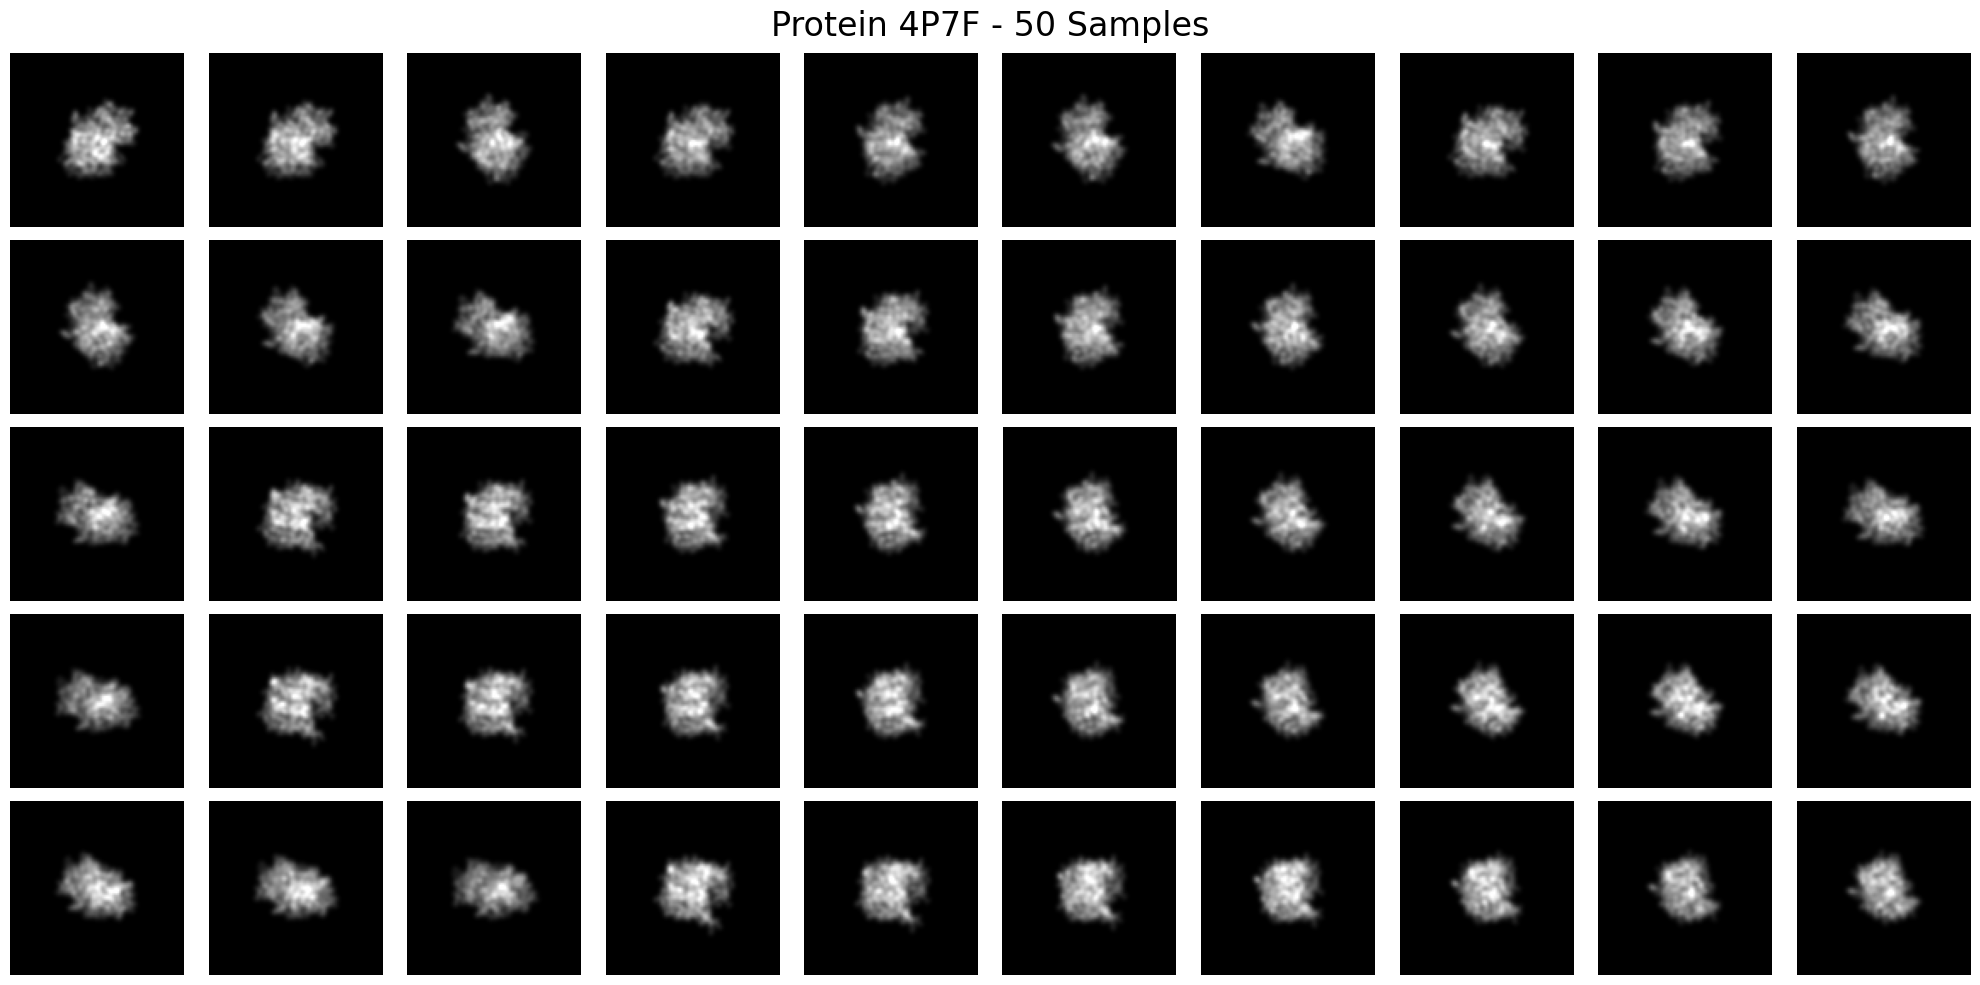

In [7]:
# print(allProteinPath[0].shape)
import matplotlib.pyplot as plt

# Assuming allProteinPath[0] has shape (50, 324, 324)
index = 107
images = allProteinPath[index]

fig, axes = plt.subplots(5, 10, figsize=(20, 10))

for i in range(50):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(images[i], cmap='gray')
    axes[row, col].axis('off')

fig.suptitle(f"Protein {class_names[index]} - 50 Samples", fontsize=24)
plt.tight_layout()
plt.show()


In [ ]:
train_image = []
train_label = []
val_image = []
val_label = []
ratio = 0.8
for idx in range(len(allProteinPath)):
    
    idx_split = round(len(allProteinPath[idx])*ratio)
    
    current_train_images = allProteinPath[idx][:idx_split]
    train_image.extend(current_train_images)
    train_label.extend([idx] * len(current_train_images))
    

    current_val_images = allProteinPath[idx][idx_split:]
    val_image.extend(current_val_images)
    val_label.extend([idx] * len(current_val_images))

print(f"number images in train data: {len(train_image)}({100*len(train_image)//(len(train_image)+len(val_image))}%)")
print(f"number images in val data: {len(val_image)}({100*len(val_image)//(len(train_image)+len(val_image))}%)")

<h1>2.2. Create Data loader for Rafdb dataset!</h1>

In [ ]:
import torch
from torch.utils.data import Dataset

class PBD42Dataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            #transforms.RandomHorizontalFlip(0.5)
        ])
    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        #print(f"max: {img.max()} -- min:{img.min()}")

        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)   # apply your transforms

        label = torch.tensor(label, dtype=torch.long)
        return img, label

train_data = PBD42Dataset(train_image, train_label)
val_data = PBD42Dataset(val_image, val_label)

train_loader = DataLoader(train_data, batch_size = 1000, shuffle=True)
val_loader = DataLoader(val_data , batch_size = 1000, shuffle=False)

<h1>2.3. Exploring Data</h1>
<h1>2.3.1 Training images in train</h1>

In [ ]:
train_image, train_label = next(iter(train_loader))

n = 21
random_index_list = random.sample(range(0, len(train_image)), n)

fig, axes = plt.subplots(3, 7, figsize=(14, 6))  # 3 rows, 7 columns

for i, ax in enumerate(axes.flat):

    img = train_image[random_index_list[i]]
    
    img = img.permute(1, 2, 0) # -> [H,W,3]
    ax.imshow(img)
    
    ax.imshow(img, cmap="gray")
    
    ax.set_title(str(class_names[train_label[random_index_list[i]].item()]).replace("_PROTEIN",""), fontsize=15)  # label as title
    ax.axis("off")  # remove axes

plt.tight_layout()
plt.show()

<h1>2.3.2 val images in val</h1>

In [ ]:
val_image, val_label = next(iter(val_loader))

n = 21
random_index_list = random.sample(range(0, len(train_image)), n)

fig, axes = plt.subplots(3, 7, figsize=(14, 6))  # 3 rows, 7 columns

for i, ax in enumerate(axes.flat):

    img = val_image[random_index_list[i]]

    img = img.permute(1, 2, 0) # -> [H,W,3]
    
    ax.imshow(img, cmap="gray")
    
    ax.set_title(str(class_names[val_label[random_index_list[i]].item()]).replace("_PROTEIN",""), fontsize=15)  # label as title
    ax.axis("off")  # remove axes

plt.tight_layout()
plt.show()

<h1>3.Loading and Setup model</h1>

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

model = None
num_classes = len(class_names)

if configs["model"] == "ResNet50":
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

elif configs["model"] == "ViT":
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

    # ViT expects 3 channels → adapt patch embedding
    model.conv_proj = nn.Conv2d(
        1,
        model.conv_proj.out_channels,
        kernel_size=model.conv_proj.kernel_size,
        stride=model.conv_proj.stride,
        padding=model.conv_proj.padding,
        bias=False,
    )

    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)

elif configs["model"] == "ConvNeXt":
    model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

    # Adapt first conv layer for grayscale
    model.features[0][0] = nn.Conv2d(
        1,
        model.features[0][0].out_channels,
        kernel_size=4,
        stride=4,
        bias=False,
    )

    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)

elif configs["model"] == "MaxViT":
    model = timm.create_model(
        "maxvit_tiny_tf_224",
        pretrained=True,
        in_chans=1,
        num_classes=num_classes
    )

else:
    raise ValueError(f"Unknown model: {configs['model']}")

print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(model)


<h1>4. Setup training process</h1>
<h1>4.1. training flow</h1>

In [ ]:
class PDB42_Trainer:
    def __init__(self, model, loss_fn, optimizer, lr_scheduler, device):
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler
        self.device = device
        self.model = model.to(device)
        self.loss_fn = loss_fn

    def train_one_epoch(self, train_loader, step_loop):
        self.model.train()
        total_loss = 0.0
        total_correct = 0
        total_examples = 0

        for i, (images, labels) in tqdm.tqdm(
        enumerate(train_loader), total = len(train_loader), leave = True, colour = "blue", desc = f"Epoch {step_loop}",
        bar_format="{desc}: {percentage:3.0f}%|{bar:50}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]"
    ):
            images = images.to(self.device)
            labels = labels.to(self.device)

            logits = self.model(images)
            loss = self.loss_fn(logits, labels)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size

            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += batch_size

        avg_loss = total_loss / total_examples
        accuracy = total_correct / total_examples
        return avg_loss, accuracy

    def evaluate(self, val_loader, step_loop):
        self.model.eval()  # evaluation mode
        total_loss = 0.0
        total_correct = 0
        total_examples = 0
    
        with torch.no_grad():  # disable gradient computation
            for i, (images, labels) in tqdm.tqdm(
                enumerate(val_loader), total = len(val_loader), leave = True, colour = "green", desc = f"Epoch {step_loop}",
                bar_format="{desc}: {percentage:3.0f}%|{bar:50}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]"
            ):
                images = images.to(self.device)
                labels = labels.to(self.device)
    
                # Forward pass
                logits = self.model(images)
                loss = loss_fn(logits, labels)
    
                batch_size = labels.size(0)
                total_loss += loss.item() * batch_size  # weight by batch size
                total_correct += (logits.argmax(dim=1) == labels).sum().item()
                total_examples += batch_size
    
        avg_loss = total_loss / total_examples
        accuracy = total_correct / total_examples
        return avg_loss, accuracy

    def run(self, epochs, train_loader, val_loader):
        self.train_loss_list = []
        self.train_acc_list = []
        self.val_loss_list = []
        self.val_acc_list = []
        self.best_train_acc = 0.0
        self.best_val_acc = 0.0
        self.best_train_loss = 0.0
        self.best_val_loss = 0.0

        for epoch in range(1, epochs + 1):
            train_loss, train_acc = self.train_one_epoch(train_loader, step_loop = epoch)
            self.train_loss_list.append(train_loss)
            self.train_acc_list.append(train_acc)
            
            val_loss, val_acc = self.evaluate(val_loader, step_loop = epoch)
            self.val_loss_list.append(val_loss)
            self.val_acc_list.append(val_acc)

            self.lr_scheduler.step()

            # 🔍 Get current LR
            current_lr = self.optimizer.param_groups[0]["lr"]
            
            print(
                f"Epoch: {epoch:02d} | "
                f"train loss: {train_loss:.4f}, train acc: {train_acc*100:.2f}% |"
                f"val loss: {val_loss:.4f}, val acc: {val_acc*100:.2f}% |"
                f"learning rate: {self.optimizer.param_groups[0]["lr"]:.4f}%"
            )

            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                self.best_val_loss = val_loss

                self.best_train_acc = train_loss
                self.best_train_loss = train_acc
                print(f"Saved new best model at epoch {epoch}")

                state = {
                    **configs,
                    "net": self.model.state_dict(),
                    "best_val_loss": self.best_val_loss,
                    "best_val_acc": self.best_val_acc,
                    "best_train_loss": self.best_train_loss,
                    "best_train_acc": self.best_train_acc,
                    "train_loss_list": self.train_loss_list,
                    "val_loss_list": self.val_loss_list,
                    "train_acc_list": self.train_acc_list,
                    "val_acc_list": self.val_acc_list,
                    "optimizer": self.optimizer.state_dict(),
                }
            
                torch.save(state, configs['rs_dir'])

<h1>4.2. Loss function</h1>

In [ ]:
loss_fn = nn.CrossEntropyLoss()

<h1>4.3. Optimizer</h1>

In [ ]:
optimizer = None
if configs['optimizer_chose'] == "RAdam":
      print("The selected optimizer is RAdam")
      optimizer = torch.optim.RAdam(
        params = model.parameters(),
        lr=configs['lr'],
    )

<h1>4.4 Learning rate scheduler</h1>

In [ ]:
lr_scheduler = None
if configs["lr_scheduler"] == "CosineAnnealingLR":
    print("The selected Lr Scheduler is CosineAnnealingLR")
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer = optimizer,
    T_max=10,     
    eta_min=1e-6      
    )

<h1>5. Start training and Evaluating</h1>

In [ ]:
train_loader = DataLoader(train_data, batch_size = configs["batch_size"], shuffle=True)
val_loader = DataLoader(val_data , batch_size = configs["batch_size"], shuffle=False)

In [ ]:
#my_trainer = PDB42_Trainer(model=model, loss_fn=loss_fn, optimizer=optimizer, lr_scheduler=lr_scheduler, device=device)
#my_trainer.run(epochs=configs['max_epoch_num'], train_loader=train_loader, val_loader=val_loader)

def train_one_epoch(train_loader, step_loop):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for i, (images, labels) in tqdm.tqdm(
    enumerate(train_loader), total = len(train_loader), leave = True, colour = "blue", desc = f"Epoch {step_loop}",
    bar_format="{desc}: {percentage:3.0f}%|{bar:50}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]"
):
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += batch_size

    avg_loss = total_loss / total_examples
    accuracy = total_correct / total_examples
    return avg_loss, accuracy

def evaluate(val_loader, step_loop):
    model.eval()  # evaluation mode
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():  # disable gradient computation
        for i, (images, labels) in tqdm.tqdm(
            enumerate(val_loader), total = len(val_loader), leave = True, colour = "green", desc = f"Epoch {step_loop}",
            bar_format="{desc}: {percentage:3.0f}%|{bar:50}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]"
        ):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            logits = model(images)
            loss = loss_fn(logits, labels)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size  # weight by batch size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += batch_size

            #print(f"total_correct: {total_correct}  -- total_examples:{total_examples}")

    avg_loss = total_loss / total_examples
    accuracy = total_correct / total_examples
    return avg_loss, accuracy


train_loss_list = []
train_acc_list = []
val_loss_list = []
val_acc_list = []
lr_list = []
best_train_acc = 0.0
best_val_acc = 0.0
best_train_loss = 0.0
best_val_loss = 0.0

epochs=configs['max_epoch_num']
early_stop_flag = 0
# os.environ['WANDB_API_KEY'] = configs["wandb_api_key"]
# wandb.login(key=configs["wandb_api_key"])
# wandb.init(
#     project = configs["project_name"],  # replace with your project name
#     config = configs,  # optional, logs all your configs
# )

# wandb.watch(model, log="all", log_freq=10)
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(train_loader, step_loop = epoch)
    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    
    val_loss, val_acc = evaluate(val_loader, step_loop = epoch)
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    for param_group in optimizer.param_groups:
        if param_group["lr"] < configs["min_lr"]:
            param_group["lr"] = configs["min_lr"]

    current_lr = optimizer.param_groups[0]["lr"]

        
    lr_list.append(current_lr)
    print(
        f"Epoch: {epoch:02d} | "
        f"train loss: {train_loss:.4f}, train acc: {train_acc*100:.2f}% |"
        f"val loss: {val_loss:.4f}, val acc: {val_acc*100:.2f}% |"
        f"learning rate: {optimizer.param_groups[0]["lr"]:.7f}%"
    )

    lr_scheduler.step()
    # Log metrics to wandb
    # wandb.log({
    #     "epoch": epoch,
    #     "train_loss": train_loss,
    #     "train_acc": train_acc,
    #     "val_loss": val_loss,
    #     "val_acc": val_acc,
    #     "lr": current_lr,
    # })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss

        best_train_acc = train_loss
        best_train_loss = train_acc
        early_stop_flag = 0
        print(f"Saved new best model at epoch {epoch}")

        state = {
            **configs,
            "net": model.state_dict(),
            "best_val_loss": best_val_loss,
            "best_val_acc": best_val_acc,
            "best_train_loss": best_train_loss,
            "best_train_acc": best_train_acc,
            "train_loss_list": train_loss_list,
            "val_loss_list": val_loss_list,
            "train_acc_list": train_acc_list,
            "val_acc_list": val_acc_list,
            "class_names": class_names,
            "optimizer": optimizer.state_dict(),
        }
    
        torch.save(state, configs['rs_dir'])
    early_stop_flag = early_stop_flag + 1
    if early_stop_flag > configs['earlyStopping']:
        print(f"early stoping is activated at epoch = {epoch}")
        break

<h1>5.1 Result</h1>

In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 15))  # 3 rows, 1 column

epoch_list =[i for i in range(1,len(train_acc_list)+1)]

# 1️⃣ Val Accuracy vs Test Accuracy
axes[0].plot(epoch_list, train_acc_list, marker='o', color='blue', label='Train Accuracy')
axes[0].plot(epoch_list, val_acc_list, marker='o', color='green', label='Val Accuracy')
axes[0].set_xticks(epoch_list)
axes[0].set_title("Validation vs train Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# 2️⃣ Train Loss vs Validation Loss
axes[1].plot(epoch_list, train_loss_list, marker='o', color='red', label='Train Loss')
axes[1].plot(epoch_list, val_loss_list, marker='o', color='orange', label='Val Loss')
axes[1].set_title("Train vs Validation Loss")
axes[1].set_xticks(epoch_list)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

# 3️⃣ Learning Rate
axes[2].plot(epoch_list, lr_list, marker='o', color='purple')
axes[2].set_title("Learning Rate over Epochs")
axes[2].set_xticks(epoch_list)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].grid(True)

plt.tight_layout()
plt.show()


<h1> 6. test Images</h1>
<h1> 6.1 Loading testing images</h1>

In [ ]:
images_per_class = []
labels_per_class = []
allStructureInTest = {0: "HYDROLASE", 1: "LIGASE", 2: "METAL_BINDING_PROTEIN", 3: "OXIDOREDUCTASE"}
for k, v in allStructureInTest.items():
    
    structures = os.path.join(configs['test_image_path'], v)
    #print(structures)
    proteins = os.listdir(structures)
    for protein in proteins:
        path = os.path.join(structures, protein)
        label_to_find = protein.upper()
        label = next((k for k, v in class_names.items() if v == label_to_find), -1)
        image_paths = os.listdir(path)
        for image_path in image_paths:
            images_per_class.append(os.path.join(path,image_path))
            labels_per_class.append(label)

In [ ]:
n = 21
rand_idx = random.sample(range(len(images_per_class)), n)

fig, axes = plt.subplots(3, 7, figsize=(14, 6))

for i, ax in enumerate(axes.flat):
    img_path = images_per_class[rand_idx[i]]   # <-- string path
    label = labels_per_class[rand_idx[i]]

    # 🔑 Load image from path
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) 

    # Convert to numpy (optional but safe)
    img = np.array(img)


    ax.imshow(img, cmap="gray")

    ax.set_title(
        class_names[int(label)].replace("_PROTEIN", ""),
        fontsize=12
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


<h1>6.2 Testing</h1>

In [ ]:
import torch
import cv2
import numpy as np
from torchvision import transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

checkpoint_path = configs['rs_dir']

state = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(state["net"]) 
model.to(device)
model.eval() 

# Prepare results
rs_per_class = {k: [0,0] for k in class_names.keys()} # index 0=true, 1=false
y_true = []
y_pred = []

# Transform for grayscale image
transform = transforms.Compose([
    transforms.ToPILImage(),        
    transforms.Resize((224, 224)),  
    transforms.ToTensor(),          
])

for i in range(len(images_per_class)):
    img_path = images_per_class[i] 
    true_label = labels_per_class[i] 

    img = cv2.imread(img_path)              
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)    

    img_tensor = transform(img)
    img_tensor = img_tensor.unsqueeze(0).to(device) 

    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_class = probs.argmax(dim=1).item()

    y_true.append(true_label)
    y_pred.append(pred_class)
   
    # Update per-class result
    if pred_class == true_label:
        rs_per_class[true_label][0] += 1
    else: 
        rs_per_class[true_label][1] += 1

# Accuracy
total_correct = sum(1 for t, p in zip(y_true, y_pred) if t == p)
print(f"total_acc: {total_correct/len(y_true):.02f}")

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Only use labels that appear in test set
unique_labels = sorted(list(set(y_true + y_pred)))
display_labels = [class_names[i] for i in unique_labels]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Compute unique labels appearing in test
unique_labels = sorted(list(set(y_true + y_pred)))
display_labels = [class_names[i] for i in unique_labels]

# Generate classification report
report = classification_report(
    y_true, 
    y_pred, 
    target_names=display_labels,
    zero_division=0 
)

print("Classification Report:\n")
print(report)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your dictionary
data = rs_per_class

keys = list(data.keys())
value0 = np.array([data[k][0] for k in keys])
value1 = np.array([data[k][1] for k in keys])

# Compute proportions
total = value0 + value1
prop0 = np.divide(value0, total, out=np.zeros_like(value0, dtype=float), where=total!=0)
prop1 = np.divide(value1, total, out=np.zeros_like(value1, dtype=float), where=total!=0)

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(8,5))

ax.bar(keys, prop0, label='True', color='skyblue')
ax.bar(keys, prop1, bottom=prop0, label='False', color='salmon')

ax.set_xticks(keys)
ax.set_ylabel("Proportion")
ax.set_xlabel("Keys")
ax.set_title("Stacked Proportion per Key")
ax.legend()

plt.show()


<h1>---------------------Test other by Tuan---------------------</h1>

In [ ]:
test_image = []
test_label = []
ratio = 0.8
for idx in range(len(allProteinPath)):
    idx_split = round(len(allProteinPath[idx])*ratio)

    current_test_images = allProteinPath[idx][idx_split:]
    test_image.extend(current_test_images)
    test_label.extend([idx] * len(current_test_images))


print(f"number images in test data: {len(test_image)}")


In [ ]:
import torch
import cv2
from torchvision import transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

checkpoint_path = configs['rs_dir']

state = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(state["net"]) 
model.to(device)
model.eval() 

rs_per_class = {k: [0,0] for k in class_names.keys()} # index = 0 is true || 1 is false
y_true = []
y_pred = []

# Transform for grayscale image
transform = transforms.Compose([
    transforms.ToPILImage(),        # Convert np.array to PIL Image
    transforms.Resize((224, 224)),  
    transforms.ToTensor(),         # Converts to 1xHxW automatically for grayscale
])

for i in range(len(test_image)):
    img = test_image[i] 
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    true_label = test_label[i] 
    
    img_tensor = transform(img)
    
    img_tensor = img_tensor.unsqueeze(0).to(device) 

    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_class = probs.argmax(dim=1).item()

    y_true.append(true_label)
    y_pred.append(pred_class)

    if pred_class == true_label:
        rs_per_class[true_label][0] = rs_per_class[true_label][0] + 1
    else: 
        rs_per_class[true_label][1] = rs_per_class[true_label][1] + 1


# Accuracy
total_correct = sum(1 for t, p in zip(y_true, y_pred) if t == p)
print(f"total_acc: {total_correct/len(y_true):.02f}")

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Only use labels that appear in test set
unique_labels = sorted(list(set(y_true + y_pred)))
display_labels = [class_names[i] for i in unique_labels]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Compute unique labels appearing in test
unique_labels = sorted(list(set(y_true + y_pred)))
display_labels = [class_names[i] for i in unique_labels]

# Generate classification report
report = classification_report(
    y_true, 
    y_pred, 
    target_names=display_labels,
    zero_division=0 
)

print("Classification Report:\n")
print(report)
